# BLT Phase Transition Inference

Use this notebook to load a trained scikit-network GNN artifact, visualize the predicted probabilities versus temperature, estimate the critical temperature, and inspect how those probabilities distribute across all nodes.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np

from data_utils import load_split
from metrics import estimate_critical_temperature


def plot_probability_scatter(ax, temps, probs, labels, t_c, true_tc=None):
    sc = ax.scatter(
        temps,
        probs,
        c=probs,
        cmap="plasma",
        s=40,
        edgecolor="black",
        linewidth=0.25,
        alpha=0.9,
        label="Nodes",
    )
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label("Predicted probability (phase=1)")
    predicted = probs >= 0.5
    misclassified = predicted != labels
    if np.any(misclassified):
        ax.scatter(
            temps[misclassified],
            probs[misclassified],
            facecolors="none",
            edgecolor="#222222",
            marker="x",
            linewidth=1.2,
            s=60,
            label="Misclassified",
        )
    ax.axvline(t_c, color="#222222", linestyle="--", label=f"Estimated T_c={t_c:.3f}")
    if true_tc is not None:
        ax.axvline(true_tc, color="#0b4f6c", linestyle="-.", label=f"Reference T_c={true_tc:.3f}")
    ax.axhline(0.5, color="#666666", linestyle=":")
    ax.set_xlabel("Temperature")
    ax.set_ylabel("P(phase = vortex)")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc="lower right", fontsize=8)


def plot_probability_heatmap(ax, temps, probs, labels):
    order = np.argsort(temps)
    ordered_temps = temps[order]
    ordered_probs = probs[order]
    ordered_labels = labels[order]
    heat_data = np.vstack([ordered_probs, ordered_labels])
    im = ax.imshow(
        heat_data,
        aspect="auto",
        cmap="magma",
        interpolation="nearest",
        vmin=0.0,
        vmax=1.0,
    )
    cb = plt.colorbar(im, ax=ax)
    cb.set_label("Value")
    ax.set_yticks([0, 1], ["Predicted probability", "True label"])
    ax.set_yticks([0.5, 1.5], minor=True)
    ax.grid(which="minor", color="white", linewidth=1)
    tick_positions = np.linspace(0, len(order) - 1, 6, dtype=int)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([f"{ordered_temps[idx]:.2f}" for idx in tick_positions], rotation=45, ha="right")
    ax.set_xlabel("Temperature (sorted)")
    ax.set_title("Node-wise heatmap")
    return ordered_temps, ordered_probs, ordered_labels


def plot_temperature_windows(axes, temps, probs, labels, t_c):
    order = np.argsort(temps)
    temps_sorted = temps[order]
    probs_sorted = probs[order]
    labels_sorted = labels[order]
    splits = np.array_split(np.arange(len(temps_sorted)), len(axes))

    for ax, idxs in zip(axes, splits):
        if len(idxs) == 0:
            continue
        t_chunk = temps_sorted[idxs]
        p_chunk = probs_sorted[idxs]
        l_chunk = labels_sorted[idxs]
        ax.scatter(
            t_chunk,
            p_chunk,
            c=p_chunk,
            cmap="plasma",
            s=35,
            edgecolor="black",
            linewidth=0.2,
            alpha=0.9,
        )
        ax.axvline(t_c, color="#555555", linestyle="--", linewidth=1)
        ax.axhline(0.5, color="#777777", linestyle=":", linewidth=0.8)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlim(t_chunk.min() - 0.02, t_chunk.max() + 0.02)
        ax.set_title(f"T ∈ [{t_chunk.min():.2f}, {t_chunk.max():.2f}]")
        ax.set_xlabel("Temperature")
        if ax is axes[0]:
            ax.set_ylabel("P(phase=1)")
        predicted = p_chunk >= 0.5
        misclassified = predicted != l_chunk
        if np.any(misclassified):
            ax.scatter(
                t_chunk[misclassified],
                p_chunk[misclassified],
                facecolors="none",
                edgecolor="#222222",
                marker="x",
                linewidth=1.0,
                s=50,
            )

In [4]:
ARTIFACT_PATH = Path("artifacts/gnn_model.joblib")
DATASET_PATH = Path("../blt_dataset_large/train.npz")
OUTPUT_PATH = Path("artifacts/inference_plot.png")
TRUE_TC = 0.89  # Set to None to auto-read from metadata.json if available

Estimated critical temperature: 0.854
Reference critical temperature: 0.890


/var/folders/jd/xnplsbnn07b_2rrq9hwhvdzw0000gn/T/ipykernel_63901/595491956.py:31: UserWarning: You passed a edgecolor/edgecolors ('#222222') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/var/folders/jd/xnplsbnn07b_2rrq9hwhvdzw0000gn/T/ipykernel_63901/595491956.py:112: UserWarning: You passed a edgecolor/edgecolors ('#222222') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


Saved visualization to artifacts/inference_plot.png


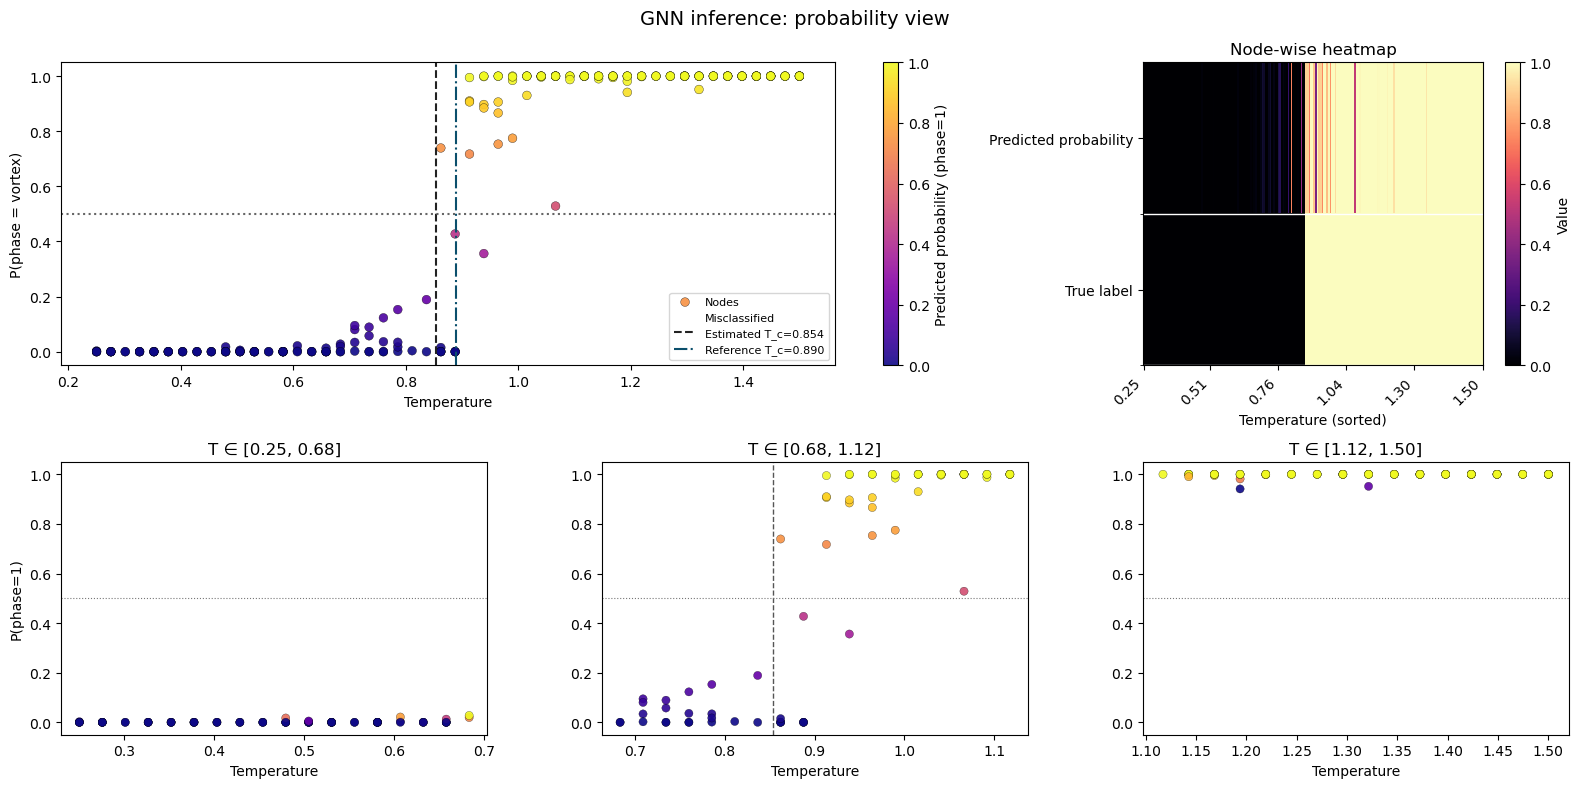

In [5]:
artifact = joblib.load(ARTIFACT_PATH)
probs = np.asarray(artifact["train_probabilities"])
temps = np.asarray(artifact["train_temperatures"])
_, _, true_labels = load_split(DATASET_PATH)
if len(true_labels) != len(probs):
    print("Warning: dataset length mismatch. Using artifact ordering only.")
    true_labels = np.zeros_like(probs, dtype=int)

true_tc = TRUE_TC
if true_tc is None:
    metadata_path = DATASET_PATH.parent / "metadata.json"
    if metadata_path.exists():
        with metadata_path.open() as f:
            true_tc = json.load(f).get("critical_temp")
        if true_tc is not None:
            print(f"Loaded reference T_c={true_tc:.3f} from metadata.json")

t_c = estimate_critical_temperature(temps, probs)
print(f"Estimated critical temperature: {t_c:.3f}")
if true_tc is not None:
    print(f"Reference critical temperature: {true_tc:.3f}")

fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 0.9])
ax_scatter = fig.add_subplot(gs[0, :2])
ax_heatmap = fig.add_subplot(gs[0, 2])
window_axes = [fig.add_subplot(gs[1, i]) for i in range(3)]

plot_probability_scatter(ax_scatter, temps, probs, true_labels, t_c, true_tc=true_tc)
plot_probability_heatmap(ax_heatmap, temps, probs, true_labels)
plot_temperature_windows(window_axes, temps, probs, true_labels, t_c)

fig.suptitle("GNN inference: probability view", fontsize=14)
fig.tight_layout()
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_PATH, dpi=200)
print(f"Saved visualization to {OUTPUT_PATH}")

### Interpreting the plot
- **Probability scatter:** each point is a simulation snapshot/node. Color intensity encodes the model’s predicted probability of being in the vortex-dominated phase. Dashed and dash-dotted vertical lines mark the inferred and reference critical temperatures, and hollow × markers denote misclassified nodes.
- **Node heatmap:** rows show the predicted probability and the true label for every node after sorting by temperature. This highlights how the network transitions from the bound-pair phase to the vortex-dominated phase.